In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r"gender classification.csv")
data.head()

,Favorite Color,Favorite Music Genre,Favorite Beverage,Favorite Soft Drink,Gender
0,Cool,Rock,Vodka,7UP/Sprite,F
1,Neutral,Hip hop,Vodka,Coca Cola/Pepsi,F
2,Warm,Rock,Wine,Coca Cola/Pepsi,F
3,Warm,Folk/Traditional,Whiskey,Fanta,F
4,Cool,Rock,Vodka,Coca Cola/Pepsi,F


In [3]:
# target variale - gender
# use accuracy score to evaluate the model

# Exploratory Data analysis

In [8]:
df = data.copy()
df.head()

,Favorite Color,Favorite Music Genre,Favorite Beverage,Favorite Soft Drink,Gender
0,Cool,Rock,Vodka,7UP/Sprite,F
1,Neutral,Hip hop,Vodka,Coca Cola/Pepsi,F
2,Warm,Rock,Wine,Coca Cola/Pepsi,F
3,Warm,Folk/Traditional,Whiskey,Fanta,F
4,Cool,Rock,Vodka,Coca Cola/Pepsi,F


In [10]:
df['Gender'] = df['Gender'].map(lambda x: 0 if x=='F' else 1)
df.head(2)


,Favorite Color,Favorite Music Genre,Favorite Beverage,Favorite Soft Drink,Gender
0,Cool,Rock,Vodka,7UP/Sprite,0
1,Neutral,Hip hop,Vodka,Coca Cola/Pepsi,0


In [12]:
df.groupby('Gender').size()

Gender
0    33
1    33
dtype: int64

In [13]:
df.shape

(66, 5)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Favorite Color        66 non-null     str  
 1   Favorite Music Genre  66 non-null     str  
 2   Favorite Beverage     66 non-null     str  
 3   Favorite Soft Drink   66 non-null     str  
 4   Gender                66 non-null     int64
dtypes: int64(1), str(4)
memory usage: 4.5 KB


In [15]:
df.isna().sum()

Favorite Color          0
Favorite Music Genre    0
Favorite Beverage       0
Favorite Soft Drink     0
Gender                  0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(4)

In [18]:
df[df.duplicated()]

,Favorite Color,Favorite Music Genre,Favorite Beverage,Favorite Soft Drink,Gender
18,Cool,Rock,Other,Coca Cola/Pepsi,0
22,Cool,Rock,Vodka,Coca Cola/Pepsi,0
61,Cool,Rock,Vodka,Coca Cola/Pepsi,1
62,Cool,Hip hop,Beer,Coca Cola/Pepsi,1


In [19]:
def missing(df):
    missing_number = df.isna().sum().sort_values(ascending=False)
    missing_percent = (df.isna().sum() / df.isna().count()).sort_values(ascending=False)
    missing_values = pd.concat([missing_number, missing_percent], axis=1, keys=['Missing_Number','Missing_Percent'])
    return missing_values

missing(df)

,Missing_Number,Missing_Percent
Favorite Color,0,0.0
Favorite Music Genre,0,0.0
Favorite Beverage,0,0.0
Favorite Soft Drink,0,0.0
Gender,0,0.0


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Favorite Color        66 non-null     str  
 1   Favorite Music Genre  66 non-null     str  
 2   Favorite Beverage     66 non-null     str  
 3   Favorite Soft Drink   66 non-null     str  
 4   Gender                66 non-null     int64
dtypes: int64(1), str(4)
memory usage: 4.5 KB


In [22]:
numerical = df.drop('Gender', axis=1).select_dtypes('number').columns
numerical

Index([], dtype='str')

In [23]:
categorical=df.select_dtypes('str').columns
categorical

Index(['Favorite Color', 'Favorite Music Genre', 'Favorite Beverage',
       'Favorite Soft Drink'],
      dtype='str')

In [25]:
df[categorical].columns

Index(['Favorite Color', 'Favorite Music Genre', 'Favorite Beverage',
       'Favorite Soft Drink'],
      dtype='str')

In [26]:
df[categorical].nunique()

Favorite Color          3
Favorite Music Genre    7
Favorite Beverage       6
Favorite Soft Drink     4
dtype: int64

In [27]:
y = df['Gender']
y.value_counts()

Gender
0    33
1    33
Name: count, dtype: int64

In [41]:
print(f"Percentage of female respondents: {round(y.value_counts(normalize=True)[0]*100,2)} % ---> ({y.value_counts()[0]} patient)")
print(f"Percentage of Male respondents: {round(y.value_counts(normalize=True)[1]*100,2)} % --->({y.value_counts()[1]} patient)")

Percentage of female respondents: 50.0 % ---> (33 patient)
Percentage of Male respondents: 50.0 % --->(33 patient)


<Axes: xlabel='Gender', ylabel='Count'>

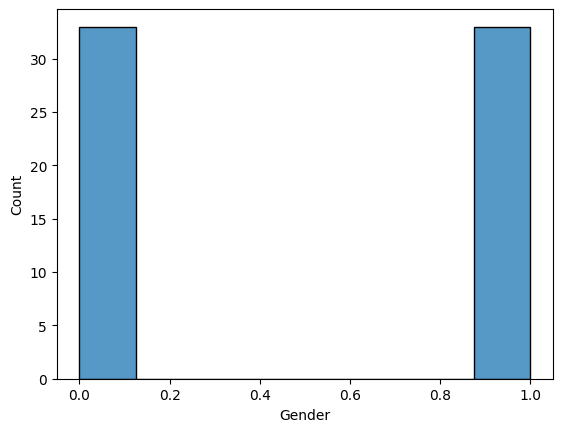

In [45]:
sns.histplot(df.Gender)

In [46]:
# categorical features
df[categorical].head()

,Favorite Color,Favorite Music Genre,Favorite Beverage,Favorite Soft Drink
0,Cool,Rock,Vodka,7UP/Sprite
1,Neutral,Hip hop,Vodka,Coca Cola/Pepsi
2,Warm,Rock,Wine,Coca Cola/Pepsi
3,Warm,Folk/Traditional,Whiskey,Fanta
4,Cool,Rock,Vodka,Coca Cola/Pepsi


# Favorite color vs Gender

In [47]:
df['Favorite Color'].unique()

<ArrowStringArray>
['Cool', 'Neutral', 'Warm']
Length: 3, dtype: str

In [49]:
df[df['Favorite Color']=='Cool']['Gender'].value_counts()

Gender
1    20
0    17
Name: count, dtype: int64

In [51]:
df[df['Favorite Color']=='Cool']['Gender'].value_counts(normalize=True)

Gender
1    0.540541
0    0.459459
Name: proportion, dtype: float64

In [52]:
df[df['Favorite Color']=='Neutral']['Gender'].value_counts()

Gender
1    4
0    3
Name: count, dtype: int64

In [54]:
df[df['Favorite Color']=='Neutral']['Gender'].value_counts(normalize=True)

Gender
1    0.571429
0    0.428571
Name: proportion, dtype: float64

In [55]:
df[df['Favorite Color']=='Warm']['Gender'].value_counts()

Gender
0    13
1     9
Name: count, dtype: int64

In [56]:
df[df['Favorite Color']=='Warm']['Gender'].value_counts(normalize=True)

Gender
0    0.590909
1    0.409091
Name: proportion, dtype: float64

In [57]:
df.groupby('Favorite Color')['Gender'].value_counts()

Favorite Color  Gender
Cool            1         20
                0         17
Neutral         1          4
                0          3
Warm            0         13
                1          9
Name: count, dtype: int64

In [58]:
df.groupby('Favorite Color')['Gender'].value_counts(normalize=True)

Favorite Color  Gender
Cool            1         0.540541
                0         0.459459
Neutral         1         0.571429
                0         0.428571
Warm            0         0.590909
                1         0.409091
Name: proportion, dtype: float64

<Axes: xlabel='Favorite Color', ylabel='Count'>

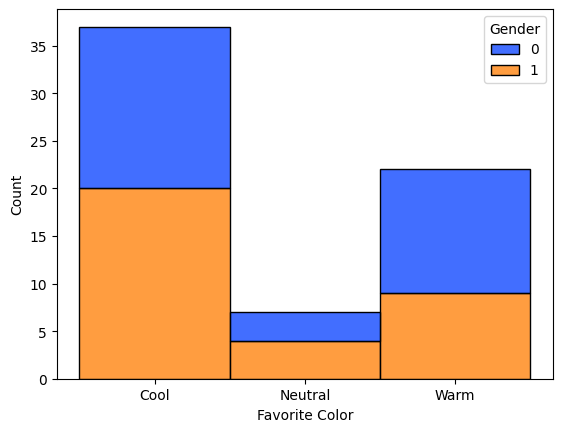

In [73]:
sns.histplot(data=df, x='Favorite Color', hue='Gender', palette='bright', multiple="stack")

<Axes: xlabel='Favorite Color', ylabel='count'>

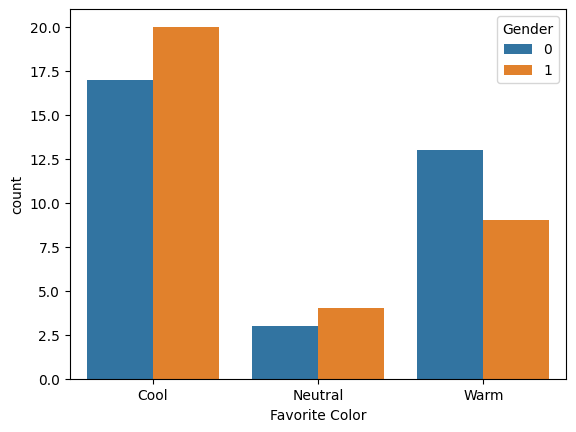

In [67]:
sns.countplot(data=df, x='Favorite Color', hue='Gender')

In [75]:
# Men[1] -- prefer 'cool and neutral' color
# women [0]--prefer 'warm' color

In [76]:
df.head(2)

,Favorite Color,Favorite Music Genre,Favorite Beverage,Favorite Soft Drink,Gender
0,Cool,Rock,Vodka,7UP/Sprite,0
1,Neutral,Hip hop,Vodka,Coca Cola/Pepsi,0


# Favorite music genre vs Gender

In [77]:
df['Favorite Music Genre'].unique()

<ArrowStringArray>
[            'Rock',          'Hip hop', 'Folk/Traditional',
       'Jazz/Blues',              'Pop',       'Electronic',
     'R&B and soul']
Length: 7, dtype: str

In [81]:
df.groupby('Favorite Music Genre')['Gender'].value_counts()

Favorite Music Genre  Gender
Electronic            1          6
                      0          2
Folk/Traditional      0          2
                      1          2
Hip hop               1          7
                      0          1
Jazz/Blues            0          3
                      1          1
Pop                   0         13
                      1          4
R&B and soul          1          4
                      0          2
Rock                  0         10
                      1          9
Name: count, dtype: int64

In [85]:
round(df.groupby('Favorite Music Genre')['Gender'].mean().sort_values(ascending=False),2)

Favorite Music Genre
Hip hop             0.88
Electronic          0.75
R&B and soul        0.67
Folk/Traditional    0.50
Rock                0.47
Jazz/Blues          0.25
Pop                 0.24
Name: Gender, dtype: float64

<Axes: xlabel='Favorite Music Genre', ylabel='Count'>

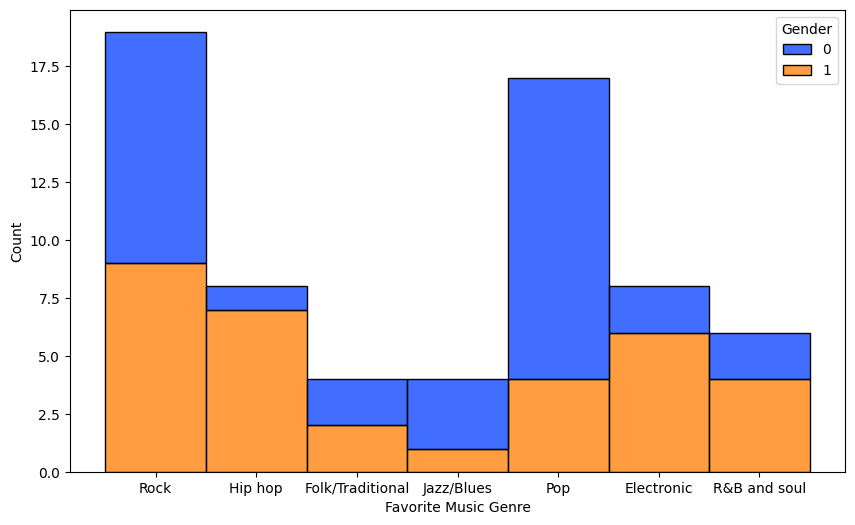

In [91]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Favorite Music Genre', hue='Gender', palette='bright', multiple='stack')

In [92]:
# men and women -- almost equally likes rock music, 'Pop' is extremply like by 'Female' whereas 'Hip hop' is less likely by 'Female'

# Favorite Beverage vs Gender

In [93]:
df['Favorite Beverage'].unique()

<ArrowStringArray>
['Vodka', 'Wine', 'Whiskey', 'Doesn't drink', 'Beer', 'Other']
Length: 6, dtype: str

In [94]:
df.groupby('Favorite Beverage')['Gender'].value_counts()

Favorite Beverage  Gender
Beer               1         7
                   0         6
Doesn't drink      1         9
                   0         5
Other              0         7
                   1         4
Vodka              1         5
                   0         4
Whiskey            0         5
                   1         4
Wine               0         6
                   1         4
Name: count, dtype: int64

In [97]:
round(df.groupby('Favorite Beverage')['Gender'].mean().sort_values(ascending=False),2)

Favorite Beverage
Doesn't drink    0.64
Vodka            0.56
Beer             0.54
Whiskey          0.44
Wine             0.40
Other            0.36
Name: Gender, dtype: float64

<Axes: xlabel='Favorite Beverage', ylabel='Count'>

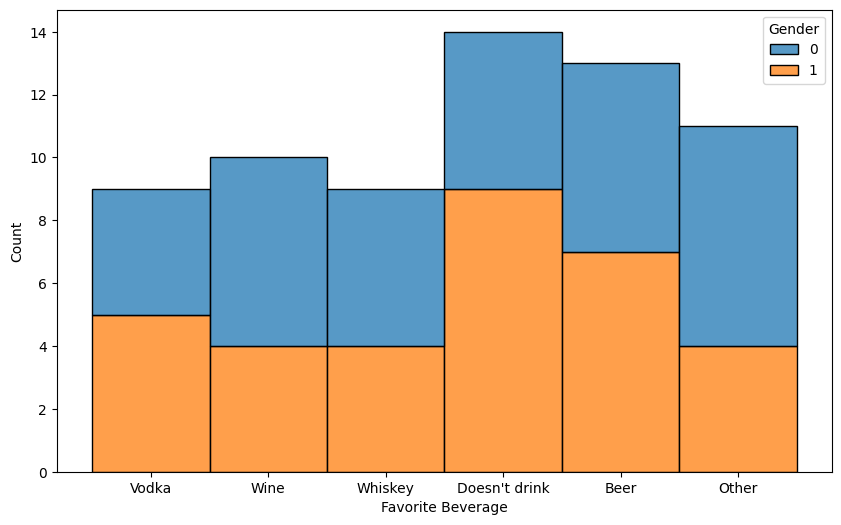

In [101]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Favorite Beverage', hue='Gender', multiple='stack')

In [109]:
df[df['Favorite Beverage'] == "Doesn't drink"]['Gender'].value_counts()

Gender
1    9
0    5
Name: count, dtype: int64

In [110]:
df[df['Favorite Beverage'] != "Doesn't drink"]['Gender'].value_counts()

Gender
0    28
1    24
Name: count, dtype: int64

In [113]:
# Female -- 28 driks but 5 donot drink
# Male --24 drinks but 9 donot drink

# Favorite Soft Drink vs Gender

In [114]:
df['Favorite Soft Drink'].unique()

<ArrowStringArray>
['7UP/Sprite', 'Coca Cola/Pepsi', 'Fanta', 'Other']
Length: 4, dtype: str

In [115]:
df.groupby('Favorite Soft Drink')['Gender'].value_counts()

Favorite Soft Drink  Gender
7UP/Sprite           0          8
                     1          5
Coca Cola/Pepsi      0         17
                     1         15
Fanta                1          8
                     0          6
Other                1          5
                     0          2
Name: count, dtype: int64

In [117]:
df.groupby('Favorite Soft Drink')['Gender'].mean().sort_values(ascending=False)

Favorite Soft Drink
Other              0.714286
Fanta              0.571429
Coca Cola/Pepsi    0.468750
7UP/Sprite         0.384615
Name: Gender, dtype: float64

In [123]:
fav_drink = df.groupby('Favorite Soft Drink')['Gender'].count().sort_values(ascending=False)
fav_drink

Favorite Soft Drink
Coca Cola/Pepsi    32
Fanta              14
7UP/Sprite         13
Other               7
Name: Gender, dtype: int64

In [120]:
df.Gender.count()

np.int64(66)

<Axes: xlabel='Favorite Soft Drink', ylabel='Count'>

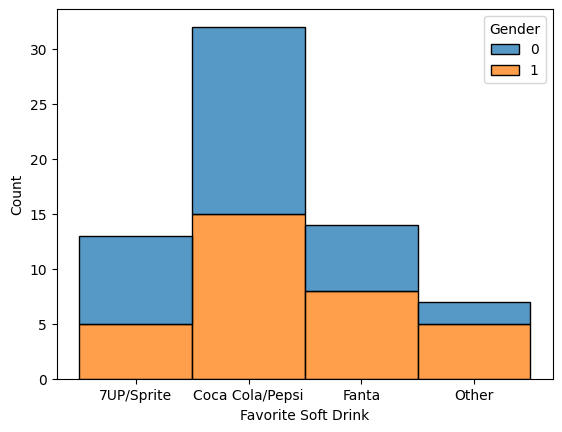

In [122]:
sns.histplot(data=df, x='Favorite Soft Drink', hue='Gender', multiple='stack')

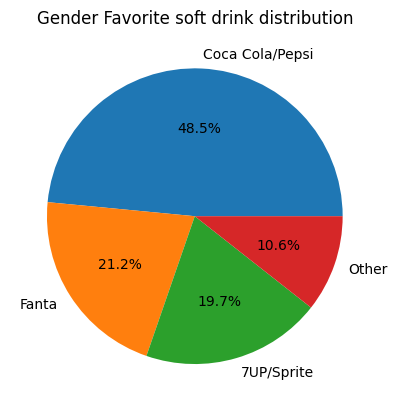

In [127]:
plt.pie(fav_drink, labels=fav_drink.index, autopct='%1.1f%%')
plt.title("Gender Favorite soft drink distribution")
plt.show()

In [128]:
# Majority of Gender prefer 'coca cola/pepsi' -- female prefer more than male
# Majority of Male prefer 'fanta and other'

# Overall insights from the EDA

In [129]:
# Target variable has perfect balanced data.
# There is no numeric feature.
# Men[1] -- prefer 'cool and neutral' color
# women [0]--prefer 'warm' color
# men and women -- almost equally likes rock music, 'Pop' is extremply like by 'Female' whereas 'Hip hop' is less likely by 'Female'
# Female -- 28 driks but 5 donot drink
# Male --24 drinks but 9 donot drink
# Majority of Gender prefer 'coca cola/pepsi' -- female prefer more than male
# Majority of Male prefer 'fanta and other'

# Model Selection

In [162]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [163]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [164]:
X = df.drop('Gender', axis=1)
y = df.Gender

In [165]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [166]:
models = {
    'LogisticRegression': LogisticRegression(),
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'RandomForestClassifier': RandomForestClassifier(),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'svm':SVC(),
}

In [167]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.compose import make_column_transformer

In [168]:
ohe = OneHotEncoder()
ct = make_column_transformer((ohe, categorical), remainder='passthrough')

In [200]:
ct

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_nam

In [169]:
accuracy = []

In [170]:
for name, model in models.items():
    pipe = make_pipeline(ct,model)
    pipe.fit(X_train,y_train)
    y_pred=pipe.predict(X_test)
    acc = accuracy_score(y_test,y_pred)
    accuracy.append(acc)
    print(f"Model name: {name}")
    print(f"Accuracy Score: {acc}")
    print("---------------")

Model name: LogisticRegression
Accuracy Score: 0.7142857142857143
---------------
Model name: DecisionTreeClassifier
Accuracy Score: 0.6428571428571429
---------------
Model name: RandomForestClassifier
Accuracy Score: 0.6428571428571429
---------------
Model name: KNeighborsClassifier
Accuracy Score: 0.5
---------------
Model name: svm
Accuracy Score: 0.7142857142857143
---------------


<Axes: >

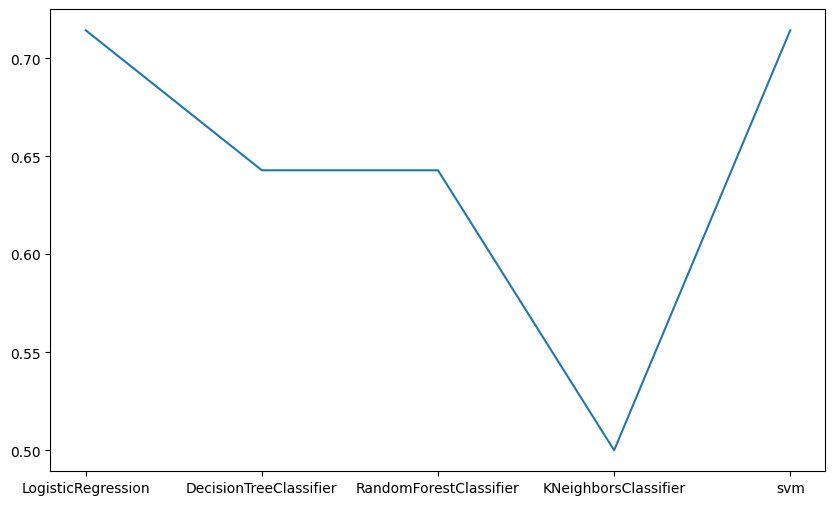

In [173]:
plt.figure(figsize=(10,6))
sns.lineplot(x=models.keys(), y=accuracy)

In [180]:
list(models.keys())

['LogisticRegression',
 'DecisionTreeClassifier',
 'RandomForestClassifier',
 'KNeighborsClassifier',
 'svm']

In [181]:
accuracy

[0.7142857142857143,
 0.6428571428571429,
 0.6428571428571429,
 0.5,
 0.7142857142857143]

In [194]:
model_acc = dict(zip(list(models.keys()), accuracy))
list(model_acc.items())

[('LogisticRegression', 0.7142857142857143),
 ('DecisionTreeClassifier', 0.6428571428571429),
 ('RandomForestClassifier', 0.6428571428571429),
 ('KNeighborsClassifier', 0.5),
 ('svm', 0.7142857142857143)]

In [199]:
result_df1 = pd.DataFrame(list(model_acc.items()), columns=[['Model Name','Accuracy']])
result_df1

,Model Name,Accuracy
0,LogisticRegression,0.714286
1,DecisionTreeClassifier,0.642857
2,RandomForestClassifier,0.642857
3,KNeighborsClassifier,0.500000
4,svm,0.714286


In [201]:
# StandardScaler

ohe = OneHotEncoder()
s = StandardScaler()
ct1 = make_column_transformer((ohe,categorical), (s,numerical))
ct1

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('standardscaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name``

In [203]:
accuracy2=[]

In [204]:
for name, model in models.items():
    pipe = make_pipeline(ct1, model)
    pipe.fit(X_train,y_train)
    y_pred = pipe.predict(X_test)
    accuracy1 = accuracy_score(y_test,y_pred)
    accuracy2.append(accuracy1)
    print(f"Model Name: {name}")
    print(f"Accuracy Score: {accuracy2}")
    print("-----------")

Model Name: LogisticRegression
Accuracy Score: [0.7142857142857143]
-----------
Model Name: DecisionTreeClassifier
Accuracy Score: [0.7142857142857143, 0.6428571428571429]
-----------
Model Name: RandomForestClassifier
Accuracy Score: [0.7142857142857143, 0.6428571428571429, 0.5714285714285714]
-----------
Model Name: KNeighborsClassifier
Accuracy Score: [0.7142857142857143, 0.6428571428571429, 0.5714285714285714, 0.5]
-----------
Model Name: svm
Accuracy Score: [0.7142857142857143, 0.6428571428571429, 0.5714285714285714, 0.5, 0.7142857142857143]
-----------


<Axes: >

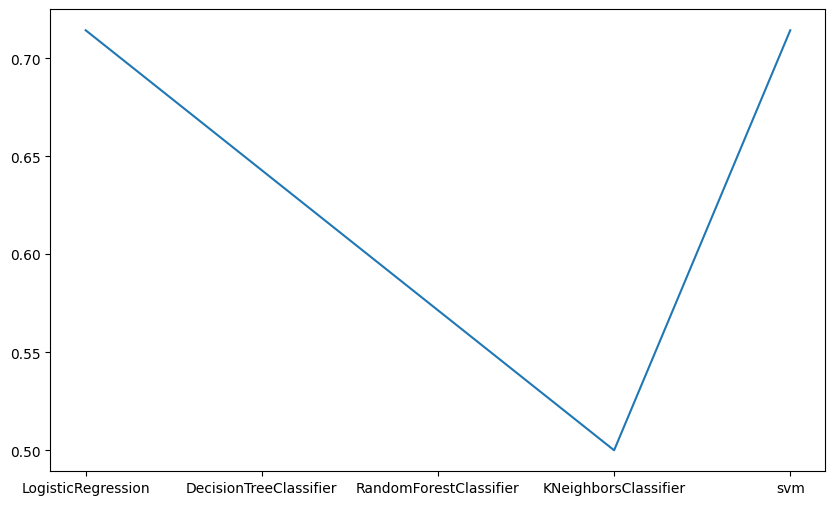

In [207]:
plt.figure(figsize=(10,6))
sns.lineplot(y=accuracy2, x=models.keys())

In [208]:
model_accuracy2 = dict(zip(models.keys(), accuracy2))
model_accuracy2

{'LogisticRegression': 0.7142857142857143,
 'DecisionTreeClassifier': 0.6428571428571429,
 'RandomForestClassifier': 0.5714285714285714,
 'KNeighborsClassifier': 0.5,
 'svm': 0.7142857142857143}

In [209]:
list(model_accuracy2.items())

[('LogisticRegression', 0.7142857142857143),
 ('DecisionTreeClassifier', 0.6428571428571429),
 ('RandomForestClassifier', 0.5714285714285714),
 ('KNeighborsClassifier', 0.5),
 ('svm', 0.7142857142857143)]

In [211]:
result_df2 = pd.DataFrame(list(model_accuracy2.items()), columns=[['Model Name','Accuracy']])
result_df2

,Model Name,Accuracy
0,LogisticRegression,0.714286
1,DecisionTreeClassifier,0.642857
2,RandomForestClassifier,0.571429
3,KNeighborsClassifier,0.500000
4,svm,0.714286
